In [3]:
import pandas as pd

data = pd.read_csv("hasil_scraper_ulasan_app_ML.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Review ID    2000 non-null   object
 1   Username     2000 non-null   object
 2   Rating       2000 non-null   int64 
 3   Review Text  2000 non-null   object
 4   Date         2000 non-null   object
dtypes: int64(1), object(4)
memory usage: 78.3+ KB


In [6]:
data.head(5)

,Review ID,Username,Rating,Review Text,Date
0,2fc30395-b4db-4921-8b72-aaa161326f9a,Aleya Dita addara,5,sumpah game nya seru banget saking seru nya ak...,2025-05-12 19:39:24
1,086e28b3-fa88-41e3-82b5-1d536f345399,Pika Chu,5,bagus tapi agak ngeselin,2025-05-12 19:38:13
2,58b50cde-00d4-4d5a-ab54-2366375447c6,Radit Nub,1,game kikir anjir,2025-05-12 19:38:10
3,dccc8791-b52f-4743-b8c7-c9703b573e8b,Sri Mulyati,1,gua dikasih dark sistem,2025-05-12 19:37:58
4,ea91c2d9-910d-4c86-b296-bec87af544f5,Carsono 7,1,lag Mulu padahal jaring ijo,2025-05-12 19:37:57


In [7]:
df = pd.DataFrame(data[['Date','Username','Rating','Review Text' ] ])
df.head(5)

,Date,Username,Rating,Review Text
0,2025-05-12 19:39:24,Aleya Dita addara,5,sumpah game nya seru banget saking seru nya ak...
1,2025-05-12 19:38:13,Pika Chu,5,bagus tapi agak ngeselin
2,2025-05-12 19:38:10,Radit Nub,1,game kikir anjir
3,2025-05-12 19:37:58,Sri Mulyati,1,gua dikasih dark sistem
4,2025-05-12 19:37:57,Carsono 7,1,lag Mulu padahal jaring ijo


# Proses hapus data duplikat

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         2000 non-null   object
 1   Username     2000 non-null   object
 2   Rating       2000 non-null   int64 
 3   Review Text  2000 non-null   object
dtypes: int64(1), object(3)
memory usage: 62.6+ KB


In [10]:
df.drop_duplicates(subset ="Review Text", keep = 'first', inplace = True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1857 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         1857 non-null   object
 1   Username     1857 non-null   object
 2   Rating       1857 non-null   int64 
 3   Review Text  1857 non-null   object
dtypes: int64(1), object(3)
memory usage: 72.5+ KB


# Wordcloud Sebelum Prepocessing

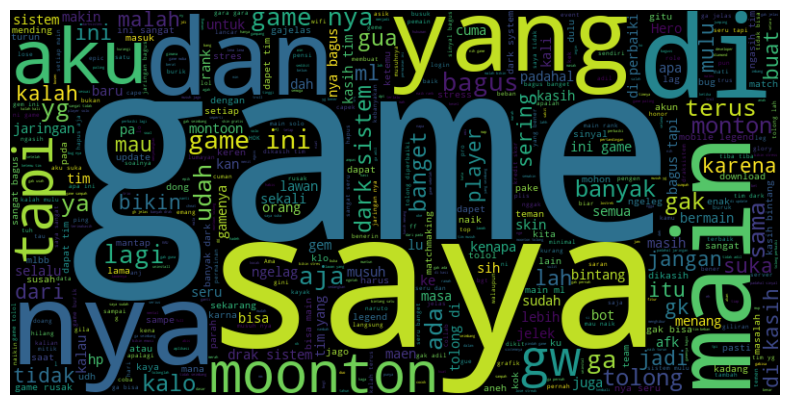

In [13]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

df['Review Text'] = df['Review Text'].fillna('')

text = ' '.join(df['Review Text'].astype(str).tolist())

stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', ' ... ', 'amp'])

wc = WordCloud(stopwords=stopwords, background_color="black", max_words=500, width=800, height=400)

wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

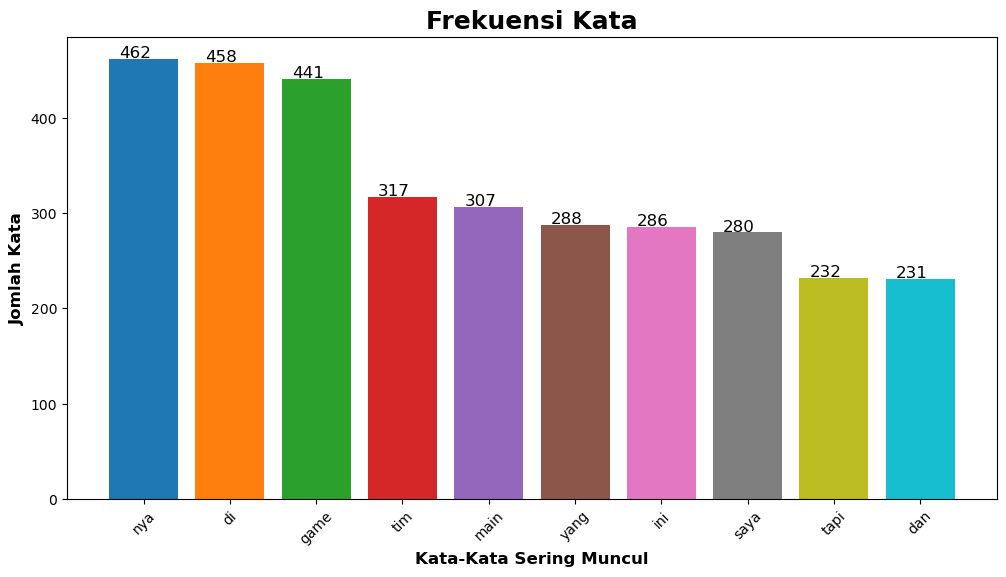

In [14]:
import matplotlib.pyplot as plt
from collections import Counter


text ="". join(df["Review Text"])

tokens = text.split()
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)
word, count = zip(*top_words)
colors = plt.cm.tab10(range(len(word)))

plt.figure(figsize=(12, 6))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jomlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# MenambahRan aogka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.1, num +1, str(num), fontsize=12, color='black', ha='center')

plt.show()
         

# 1.Proses Cleaning Data

In [16]:
import re
import string
import nltk


# Fungsi untuk menghapus URL
def remove_URL(tweet):
    if tweet is not None and isinstance(tweet, str):
        url = re.compile(r'https ?: //\S+|www\.\S+')
        return url.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus HTML
def remove_html(tweet):
    if tweet is not None and isinstance(tweet, str):
        html = re.compile(r' <.*? >')
        return html.sub(r'', tweet)
    else:
        return tweet
        
# Fungsi untuk menghapus emoji
def remove_emoji(tweet):
    if tweet is not None and isinstance(tweet, str):
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F" # emoticons
            u"\U0001F300-\U0001F5FF" # symbols & pictographs
            u"\U0001F680-\U0001F6FF" # transport & map symbols
            u"\U0001F700-\U0001F77F" # alchemical symbols
            u"\U0001F780-\U0001F7FF" # Geometric Shapes Extended
            u"\U0001F800-\U0001F8FF" # Supplemental Arrows-C
            u"\U0001F900-\U0001F9FF" # Supplemental Symbols and Pictographs
            u"\U0001FA00-\U0001FA6F" # Chess Symbols
            u"\U0001FA70-\U0001FAFF" # Symbols and Pictographs Extended-A
            u"\U0001F004-\U0001F0CF" # Additional emoticons
            u"\U0001F1E0-\U0001F1FF" # flags
                               "]+", flags=re.UNICODE)
        return emoji_pattern.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus simbol
def remove_symbols(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'[^a-zA-Z0-9\s]', '', tweet)
    return tweet

# Fungsi untuk menghapus angka
def remove_numbers(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'\d', '', tweet)
    return tweet

df['cleaning'] =df['Review Text'].apply(lambda x: remove_URL(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_html(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_emoji(x))
df['cleaning' ] = df['cleaning'].apply(lambda x: remove_symbols(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_numbers(x))

df.head(10)

,Date,Username,Rating,Review Text,cleaning
0,2025-05-12 19:39:24,Aleya Dita addara,5,sumpah game nya seru banget saking seru nya ak...,sumpah game nya seru banget saking seru nya ak...
1,2025-05-12 19:38:13,Pika Chu,5,bagus tapi agak ngeselin,bagus tapi agak ngeselin
2,2025-05-12 19:38:10,Radit Nub,1,game kikir anjir,game kikir anjir
3,2025-05-12 19:37:58,Sri Mulyati,1,gua dikasih dark sistem,gua dikasih dark sistem
4,2025-05-12 19:37:57,Carsono 7,1,lag Mulu padahal jaring ijo,lag Mulu padahal jaring ijo
5,2025-05-12 19:36:31,Hanif faisal Zahra'an altair,1,ngasih team yg bener ton capek ks 10 gw,ngasih team yg bener ton capek ks gw
6,2025-05-12 19:36:30,Muhammad Hafizh,5,game nya seru tapi bisa GK moonton mohon buff ...,game nya seru tapi bisa GK moonton mohon buff ...
7,2025-05-12 19:36:20,Oppo,1,gua dikasih tim poke sedangkan musuh jago jago,gua dikasih tim poke sedangkan musuh jago jago
8,2025-05-12 19:36:19,Alab yyinah Alba,4,geme ya numayan seru tapi aku udah simpen diam...,geme ya numayan seru tapi aku udah simpen diam...
9,2025-05-12 19:36:03,Gw Jelek,1,suka bgt ngasih musuh susah tp timnyaa bloon,suka bgt ngasih musuh susah tp timnyaa bloon


# 2.Proses Case Folding

In [18]:
def case_folding(text):
    if isinstance(text, str):
        lowercase_text = text.lower()
        return lowercase_text
    else:
        return text

df['case_folding'] = df['cleaning'].apply(case_folding)
df.head(5)

,Date,Username,Rating,Review Text,cleaning,case_folding
0,2025-05-12 19:39:24,Aleya Dita addara,5,sumpah game nya seru banget saking seru nya ak...,sumpah game nya seru banget saking seru nya ak...,sumpah game nya seru banget saking seru nya ak...
1,2025-05-12 19:38:13,Pika Chu,5,bagus tapi agak ngeselin,bagus tapi agak ngeselin,bagus tapi agak ngeselin
2,2025-05-12 19:38:10,Radit Nub,1,game kikir anjir,game kikir anjir,game kikir anjir
3,2025-05-12 19:37:58,Sri Mulyati,1,gua dikasih dark sistem,gua dikasih dark sistem,gua dikasih dark sistem
4,2025-05-12 19:37:57,Carsono 7,1,lag Mulu padahal jaring ijo,lag Mulu padahal jaring ijo,lag mulu padahal jaring ijo


# 3.Normalisasi Kata

In [20]:
import pandas as pd

# Fungsi Penggantian kata tidak baku
def replace_taboo_words(text, kamus_tidak_baku):
    if isinstance(text, str):
        words = text.split()
        replaced_words = []
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

        for word in words:
            if word in kamus_tidak_baku:
                baku_word = kamus_tidak_baku[word]
                if isinstance(baku_word, str) and all(char.isalpha() for char in baku_word):
                    replaced_words.append(baku_word)
                    kalimat_baku.append(baku_word)
                    kata_diganti.append(word)
                    kata_tidak_baku_hash.append(hash(word))
               # else:
                   # replaced_words.append('<karakter eksplisit>')
                   # kalimat_baku.append(word)
            else:
                replaced_words.append(word)
        replaced_text = ' '.join(replaced_words)
    else:
        replaced_text = ''
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

    return replaced_text, kalimat_baku, kata_diganti, kata_tidak_baku_hash


In [21]:
# Baca dataset
data = pd.DataFrame(df[['Date' ,'Username' ,'Rating' ,'Review Text','cleaning','case_folding' ]])
data.head(5)

,Date,Username,Rating,Review Text,cleaning,case_folding
0,2025-05-12 19:39:24,Aleya Dita addara,5,sumpah game nya seru banget saking seru nya ak...,sumpah game nya seru banget saking seru nya ak...,sumpah game nya seru banget saking seru nya ak...
1,2025-05-12 19:38:13,Pika Chu,5,bagus tapi agak ngeselin,bagus tapi agak ngeselin,bagus tapi agak ngeselin
2,2025-05-12 19:38:10,Radit Nub,1,game kikir anjir,game kikir anjir,game kikir anjir
3,2025-05-12 19:37:58,Sri Mulyati,1,gua dikasih dark sistem,gua dikasih dark sistem,gua dikasih dark sistem
4,2025-05-12 19:37:57,Carsono 7,1,lag Mulu padahal jaring ijo,lag Mulu padahal jaring ijo,lag mulu padahal jaring ijo


In [22]:
# Baca kamus kata tidak baku
kamus_data = pd.read_excel("kamuskatabaku.xlsx")
kamus_tidak_baku = dict(zip(kamus_data['tidak_baku'], kamus_data['kata_baku']))

In [23]:
# Terapkan fungsi penggantian kata tidak baku
data['normalisasi'], data['Kata_Baku'], data['Kata_Tidak_Baku'], data['Kata_Tidak_Baku_Hash'] = zip(*data['case_folding'].apply(lambda x: replace_taboo_words(x, kamus_tidak_baku)))

#data.head(100)

df = pd.DataFrame(data[['Date' ,'Username' ,'Rating' ,'Review Text','cleaning','case_folding','normalisasi' ]])
df.head(20)


,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi
0,2025-05-12 19:39:24,Aleya Dita addara,5,sumpah game nya seru banget saking seru nya ak...,sumpah game nya seru banget saking seru nya ak...,sumpah game nya seru banget saking seru nya ak...,sumpah game ya seru banget saking seru ya aku ...
1,2025-05-12 19:38:13,Pika Chu,5,bagus tapi agak ngeselin,bagus tapi agak ngeselin,bagus tapi agak ngeselin,bagus tapi agak mengesalkan
2,2025-05-12 19:38:10,Radit Nub,1,game kikir anjir,game kikir anjir,game kikir anjir,game kikir anjir
3,2025-05-12 19:37:58,Sri Mulyati,1,gua dikasih dark sistem,gua dikasih dark sistem,gua dikasih dark sistem,gua dikasih dark sistem
4,2025-05-12 19:37:57,Carsono 7,1,lag Mulu padahal jaring ijo,lag Mulu padahal jaring ijo,lag mulu padahal jaring ijo,lag mulu padahal jaring ijo
5,2025-05-12 19:36:31,Hanif faisal Zahra'an altair,1,ngasih team yg bener ton capek ks 10 gw,ngasih team yg bener ton capek ks gw,ngasih team yg bener ton capek ks gw,mengasih team yang benar ton capek ks gue
6,2025-05-12 19:36:30,Muhammad Hafizh,5,game nya seru tapi bisa GK moonton mohon buff ...,game nya seru tapi bisa GK moonton mohon buff ...,game nya seru tapi bisa gk moonton mohon buff ...,game ya seru tapi bisa tidak moonton mohon buf...
7,2025-05-12 19:36:20,Oppo,1,gua dikasih tim poke sedangkan musuh jago jago,gua dikasih tim poke sedangkan musuh jago jago,gua dikasih tim poke sedangkan musuh jago jago,gua dikasih tim poke sedangkan musuh jago jago
8,2025-05-12 19:36:19,Alab yyinah Alba,4,geme ya numayan seru tapi aku udah simpen diam...,geme ya numayan seru tapi aku udah simpen diam...,geme ya numayan seru tapi aku udah simpen diam...,geme ya numayan seru tapi aku sudah simpan dia...
9,2025-05-12 19:36:03,Gw Jelek,1,suka bgt ngasih musuh susah tp timnyaa bloon,suka bgt ngasih musuh susah tp timnyaa bloon,suka bgt ngasih musuh susah tp timnyaa bloon,suka banget mengasih musuh susah tapi timnyaa ...


# 4.Tokenization

In [25]:
# Mengubah data menjadi bentuk token (,) per kata

def tokenize(text):
    tokens = text.split()
    return tokens
    
df['tokenize' ] = df['normalisasi'].apply(tokenize)

df.head(5)

,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi,tokenize
0,2025-05-12 19:39:24,Aleya Dita addara,5,sumpah game nya seru banget saking seru nya ak...,sumpah game nya seru banget saking seru nya ak...,sumpah game nya seru banget saking seru nya ak...,sumpah game ya seru banget saking seru ya aku ...,"[sumpah, game, ya, seru, banget, saking, seru,..."
1,2025-05-12 19:38:13,Pika Chu,5,bagus tapi agak ngeselin,bagus tapi agak ngeselin,bagus tapi agak ngeselin,bagus tapi agak mengesalkan,"[bagus, tapi, agak, mengesalkan]"
2,2025-05-12 19:38:10,Radit Nub,1,game kikir anjir,game kikir anjir,game kikir anjir,game kikir anjir,"[game, kikir, anjir]"
3,2025-05-12 19:37:58,Sri Mulyati,1,gua dikasih dark sistem,gua dikasih dark sistem,gua dikasih dark sistem,gua dikasih dark sistem,"[gua, dikasih, dark, sistem]"
4,2025-05-12 19:37:57,Carsono 7,1,lag Mulu padahal jaring ijo,lag Mulu padahal jaring ijo,lag mulu padahal jaring ijo,lag mulu padahal jaring ijo,"[lag, mulu, padahal, jaring, ijo]"


# 5.Filtering (Stopword Removal)

**Filtering** adalah tahap mengambil kata-kata penting dari hasil token dengan menggunakan algoritma stoplist (membuang kata kurang penting) atau wordlist (menyimpan kata penting).

**Stopword** adalah kata umum yang biasanya muncul dalam jumlah besar dan dianggap tidak memiliki makna. Contoh stopword dalam bahasa Indonesia adalah “yang”, “dan”, “di”, “dari”, dll. Makna di balik penggunaan stopword yaitu dengan menghapus kata-kata yang memiliki informasi rendah dari sebuah teks, kita dapat fokus pada kata-kata penting sebagai gantinya.

Contoh penggunaan filtering dapat kita temukan pada konteks mesin pencarian. Jika permintaan pencarian anda adalah “apa itu pengertian manajemen?” tentunya anda ingin sistem pencarian fokus pada memunculkan dokumen dengan topik tentang “pengertian manajemen” di atas dokumen dengan topik “apa itu”. Hal ini dapat dilakukan dengan mencegah kata dari daftar stopword dianalisa.

https://www.kirenz.com/post/2021-12-11-text-mining-and-sentiment-analysis-with-nltk-and-pandas-in-python/text-mining-and-sentiment-analysis-with-nltk-and-pandas-in-python/

In [27]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [28]:
#Mengahpus kata-kata yang tidak penting/tidak ada nilai berdasarkan kamus NLTK
def remove_stopwords(text):
    return [word for word in text if word not in stop_words]

df['stopword removal' ] = df['tokenize'].apply(lambda x: remove_stopwords(x))

df.head(5)

,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi,tokenize,stopword removal
0,2025-05-12 19:39:24,Aleya Dita addara,5,sumpah game nya seru banget saking seru nya ak...,sumpah game nya seru banget saking seru nya ak...,sumpah game nya seru banget saking seru nya ak...,sumpah game ya seru banget saking seru ya aku ...,"[sumpah, game, ya, seru, banget, saking, seru,...","[sumpah, game, ya, seru, banget, saking, seru,..."
1,2025-05-12 19:38:13,Pika Chu,5,bagus tapi agak ngeselin,bagus tapi agak ngeselin,bagus tapi agak ngeselin,bagus tapi agak mengesalkan,"[bagus, tapi, agak, mengesalkan]","[bagus, mengesalkan]"
2,2025-05-12 19:38:10,Radit Nub,1,game kikir anjir,game kikir anjir,game kikir anjir,game kikir anjir,"[game, kikir, anjir]","[game, kikir, anjir]"
3,2025-05-12 19:37:58,Sri Mulyati,1,gua dikasih dark sistem,gua dikasih dark sistem,gua dikasih dark sistem,gua dikasih dark sistem,"[gua, dikasih, dark, sistem]","[gua, dikasih, dark, sistem]"
4,2025-05-12 19:37:57,Carsono 7,1,lag Mulu padahal jaring ijo,lag Mulu padahal jaring ijo,lag mulu padahal jaring ijo,lag mulu padahal jaring ijo,"[lag, mulu, padahal, jaring, ijo]","[lag, mulu, jaring, ijo]"


# 6.Proses Steaming Data

Sastrawi Python adalah library python sederhana yang memungkinkan Anda untuk mereduksi kata-kata infleksi dalam Bahasa Indonesia (Bahasa Indonesia) ke bentuk dasarnya (stem). Ini adalah port Python dari proyek Sastrawi asli yang ditulis dalam PHP (kredit diberikan kepada penulis asli dan kontributor Sastrawi PHP). https://medium.com/@93Kryptonian/stemming-with-sastrawi-877cc40a37ad

Stemming adalah teknik pemrosesan bahasa alami yang menurunkan infleksi kata ke bentuk akarnya, sehingga membantu dalam pra-pemrosesan teks, kata, dan dokumen untuk normalisasi teks.

Menurut Wikipedia, infleksi adalah proses di mana sebuah kata dimodifikasi untuk mengkomunikasikan banyak kategori tata bahasa, termasuk tegang, kasus, suara, aspek, orang, jumlah, jenis kelamin, dan suasana hati. Jadi, meskipun sebuah kata mungkin ada dalam beberapa bentuk infleksi, memiliki beberapa bentuk infleksi di dalam teks yang sama menambah redundansi pada proses NLP.

Akibatnya, kami menggunakan stemming untuk mengurangi kata ke bentuk dasar atau stem, yang mungkin atau mungkin bukan kata yang sah dalam bahasa tersebut.

Misalnya, batang dari ketiga kata ini, koneksi, terhubung, menghubungkan, adalah "menghubungkan". Di sisi lain, akar masalah, masalah, dan masalah adalah "masalah", yang bukan kata yang dikenal.

In [30]:
!pip install Sastrawi

from Sastrawi. Stemmer. StemmerFactory import StemmerFactory
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer


In [31]:
# Mengubah kata menjadi standar nya
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(text):
    return [stemmer.stem(word) for word in text]

df['steming_data'] = df['stopword removal'].apply(lambda x:' '.join(stem_text(x)))
df.head(5)

,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi,tokenize,stopword removal,steming_data
0,2025-05-12 19:39:24,Aleya Dita addara,5,sumpah game nya seru banget saking seru nya ak...,sumpah game nya seru banget saking seru nya ak...,sumpah game nya seru banget saking seru nya ak...,sumpah game ya seru banget saking seru ya aku ...,"[sumpah, game, ya, seru, banget, saking, seru,...","[sumpah, game, ya, seru, banget, saking, seru,...",sumpah game ya seru banget saking seru ya rank...
1,2025-05-12 19:38:13,Pika Chu,5,bagus tapi agak ngeselin,bagus tapi agak ngeselin,bagus tapi agak ngeselin,bagus tapi agak mengesalkan,"[bagus, tapi, agak, mengesalkan]","[bagus, mengesalkan]",bagus kesal
2,2025-05-12 19:38:10,Radit Nub,1,game kikir anjir,game kikir anjir,game kikir anjir,game kikir anjir,"[game, kikir, anjir]","[game, kikir, anjir]",game kikir anjir
3,2025-05-12 19:37:58,Sri Mulyati,1,gua dikasih dark sistem,gua dikasih dark sistem,gua dikasih dark sistem,gua dikasih dark sistem,"[gua, dikasih, dark, sistem]","[gua, dikasih, dark, sistem]",gua kasih dark sistem
4,2025-05-12 19:37:57,Carsono 7,1,lag Mulu padahal jaring ijo,lag Mulu padahal jaring ijo,lag mulu padahal jaring ijo,lag mulu padahal jaring ijo,"[lag, mulu, padahal, jaring, ijo]","[lag, mulu, jaring, ijo]",lag mulu jaring ijo


In [32]:
df.to_csv('Hasil_Preprocessing_ML.csv',encoding='utf8', index=False);

# Wordcloud Setelah Prepocessing

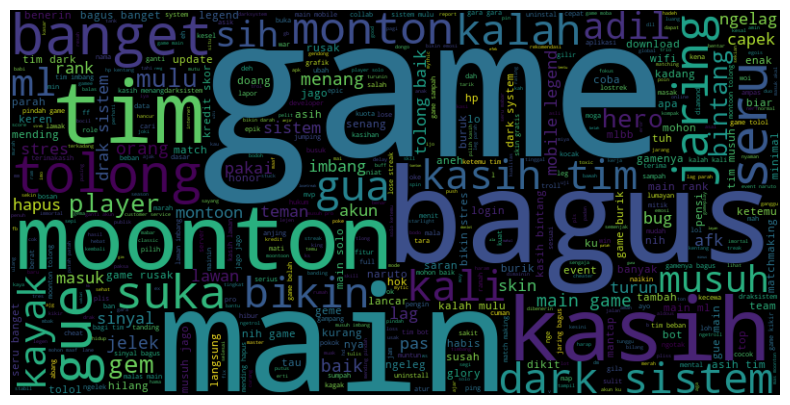

In [34]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

# Mengisi nilai NaN dengan string kosong ('')
# df['steming_data'] = df['steming_data'].fillna('')

# Menggabungkan teks dari kolom 'content'
text = ' '.join(df['steming_data'].astype(str).tolist())

stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', ' ... ', 'amp','ya'])

wc = WordCloud(stopwords=stopwords, background_color="black", max_words=500, width=800, height=400)

wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

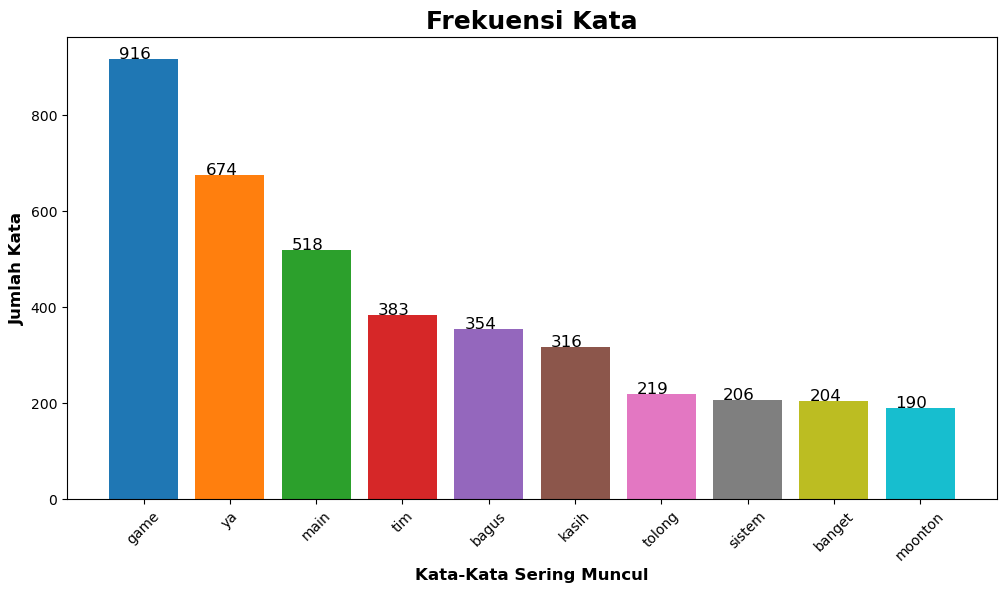

In [35]:
import matplotlib.pyplot as plt
from collections import Counter

text = " ".join(df["steming_data"])

tokens = text.split()
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)

word, count = zip(*top_words)

# Definisikan palet warna
colors = plt.cm.tab10(range(len(word)))

plt.figure(figsize=(12, 6))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

 # Menambahkan angka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')

plt.show()

# B.Pelabelan Data

In [37]:
import pandas as pd

data = pd.read_csv("Hasil_Preprocessing_ML.csv")
data.head(5)

,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi,tokenize,stopword removal,steming_data
0,2025-05-12 19:39:24,Aleya Dita addara,5,sumpah game nya seru banget saking seru nya ak...,sumpah game nya seru banget saking seru nya ak...,sumpah game nya seru banget saking seru nya ak...,sumpah game ya seru banget saking seru ya aku ...,"['sumpah', 'game', 'ya', 'seru', 'banget', 'sa...","['sumpah', 'game', 'ya', 'seru', 'banget', 'sa...",sumpah game ya seru banget saking seru ya rank...
1,2025-05-12 19:38:13,Pika Chu,5,bagus tapi agak ngeselin,bagus tapi agak ngeselin,bagus tapi agak ngeselin,bagus tapi agak mengesalkan,"['bagus', 'tapi', 'agak', 'mengesalkan']","['bagus', 'mengesalkan']",bagus kesal
2,2025-05-12 19:38:10,Radit Nub,1,game kikir anjir,game kikir anjir,game kikir anjir,game kikir anjir,"['game', 'kikir', 'anjir']","['game', 'kikir', 'anjir']",game kikir anjir
3,2025-05-12 19:37:58,Sri Mulyati,1,gua dikasih dark sistem,gua dikasih dark sistem,gua dikasih dark sistem,gua dikasih dark sistem,"['gua', 'dikasih', 'dark', 'sistem']","['gua', 'dikasih', 'dark', 'sistem']",gua kasih dark sistem
4,2025-05-12 19:37:57,Carsono 7,1,lag Mulu padahal jaring ijo,lag Mulu padahal jaring ijo,lag mulu padahal jaring ijo,lag mulu padahal jaring ijo,"['lag', 'mulu', 'padahal', 'jaring', 'ijo']","['lag', 'mulu', 'jaring', 'ijo']",lag mulu jaring ijo


In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1857 entries, 0 to 1856
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              1857 non-null   object
 1   Username          1857 non-null   object
 2   Rating            1857 non-null   int64 
 3   Review Text       1857 non-null   object
 4   cleaning          1848 non-null   object
 5   case_folding      1848 non-null   object
 6   normalisasi       1846 non-null   object
 7   tokenize          1857 non-null   object
 8   stopword removal  1857 non-null   object
 9   steming_data      1840 non-null   object
dtypes: int64(1), object(9)
memory usage: 145.2+ KB


In [39]:
data = data.dropna()

In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1840 entries, 0 to 1856
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              1840 non-null   object
 1   Username          1840 non-null   object
 2   Rating            1840 non-null   int64 
 3   Review Text       1840 non-null   object
 4   cleaning          1840 non-null   object
 5   case_folding      1840 non-null   object
 6   normalisasi       1840 non-null   object
 7   tokenize          1840 non-null   object
 8   stopword removal  1840 non-null   object
 9   steming_data      1840 non-null   object
dtypes: int64(1), object(9)
memory usage: 158.1+ KB


In [41]:
data = pd.DataFrame(data[['steming_data','Rating']])
data.head(5)

,steming_data,Rating
0,sumpah game ya seru banget saking seru ya rank...,5
1,bagus kesal,5
2,game kikir anjir,1
3,gua kasih dark sistem,1
4,lag mulu jaring ijo,1


In [42]:
data['Sentiment'] = data['Rating'].apply(lambda x: 'Negatif' if x <= 3 else 'Positif')
data.head()

,steming_data,Rating,Sentiment
0,sumpah game ya seru banget saking seru ya rank...,5,Positif
1,bagus kesal,5,Positif
2,game kikir anjir,1,Negatif
3,gua kasih dark sistem,1,Negatif
4,lag mulu jaring ijo,1,Negatif


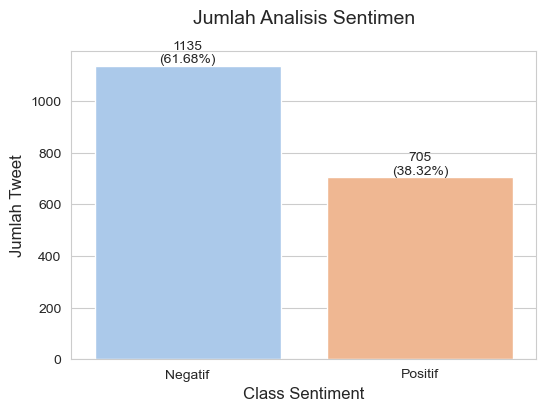

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sentiment_count = data['Sentiment' ]. value_counts ()
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, hue=sentiment_count.index, palette='pastel', legend=False)
plt.title('Jumlah Analisis Sentimen', fontsize=14, pad=20)
plt.xlabel('Class Sentiment', fontsize=12)
plt.ylabel('Jumlah Tweet', fontsize=12)

total = len(data['Sentiment'])

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'  # Hapus spasi setelah ":"
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

    
plt.show()



In [44]:
data.to_csv('Hasil_Labelling_Data_ML.csv',encoding='utf8', index=False)

# Wordcloud Sentimen Positif Dan Negatif

In [46]:
import pandas as pd

data = pd.read_csv("Hasil_Labelling_Data_ML.csv")
data.head(5)

,steming_data,Rating,Sentiment
0,sumpah game ya seru banget saking seru ya rank...,5,Positif
1,bagus kesal,5,Positif
2,game kikir anjir,1,Negatif
3,gua kasih dark sistem,1,Negatif
4,lag mulu jaring ijo,1,Negatif


In [47]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Pisahkan dataset berdasarkan sentimen
sentimen_Negative = data.loc[data['Sentiment'] == 'Negatif', 'steming_data'].str.cat(sep=' ')
sentimen_Positive = data.loc[data['Sentiment'] == 'Positif', 'steming_data'].str.cat(sep=' ')


In [48]:
# Fungsi untuk membuat dan menampilkan Wordcloud
def create_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, random_state=42, max_font_size=100, background_color='white').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

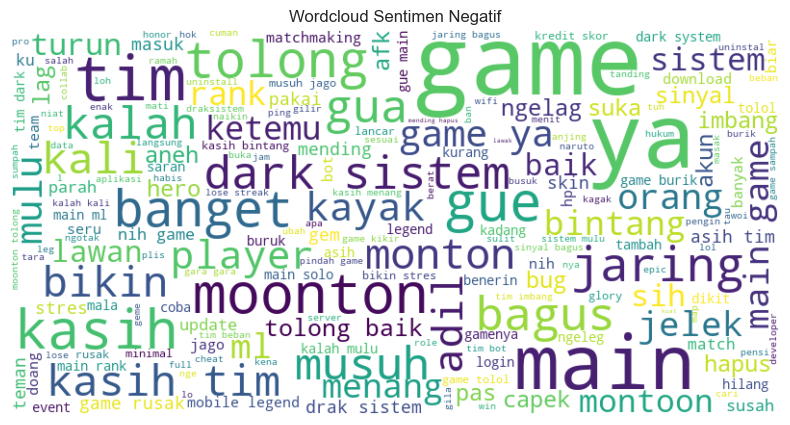

In [49]:
# Membuat Wordcloud untuk sentimen Negatif
create_wordcloud(sentimen_Negative, 'Wordcloud Sentimen Negatif')

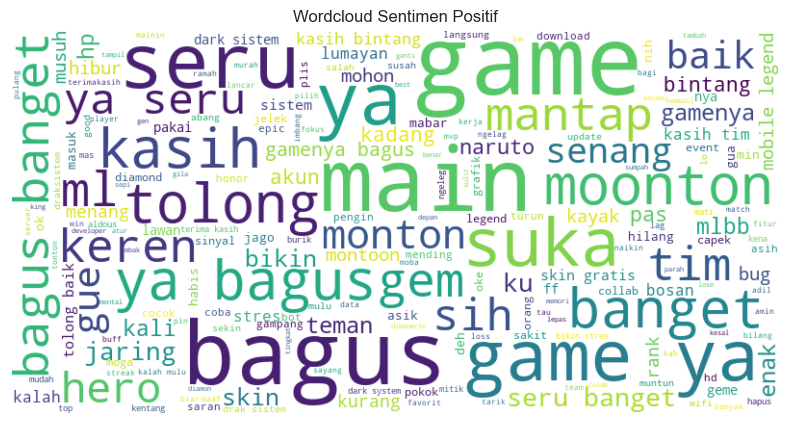

In [50]:
# Membuat Wordcloud untuk sentimen Negatif
create_wordcloud(sentimen_Positive, 'Wordcloud Sentimen Positif')

# C. Splitting Data

In [1]:
import pandas as pd

file_path = 'Hasil_Labelling_Data_ML.csv'
data = pd.read_csv(file_path)

data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1840 entries, 0 to 1839
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   steming_data  1840 non-null   object
 1   Rating        1840 non-null   int64 
 2   Sentiment     1840 non-null   object
dtypes: int64(1), object(2)
memory usage: 43.3+ KB


,steming_data,Rating,Sentiment
0,sumpah game ya seru banget saking seru ya rank...,5,Positif
1,bagus kesal,5,Positif
2,game kikir anjir,1,Negatif
3,gua kasih dark sistem,1,Negatif
4,lag mulu jaring ijo,1,Negatif


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer


cleaned_data = data.dropna(subset=['steming_data'])

x = cleaned_data['steming_data']
y = cleaned_data['Sentiment']


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print("Jumlah data latih:", len(x_train))
print("Jumlah data uji:", len(x_test))
print('============================')

vectorizer = TfidfVectorizer()
x_train_vec = vectorizer.fit_transform(x_train)
x_test_vec = vectorizer.transform(x_test)

x_train_vec.shape, x_test_vec. shape

Jumlah data latih: 1472
Jumlah data uji: 368


((1472, 2361), (368, 2361))

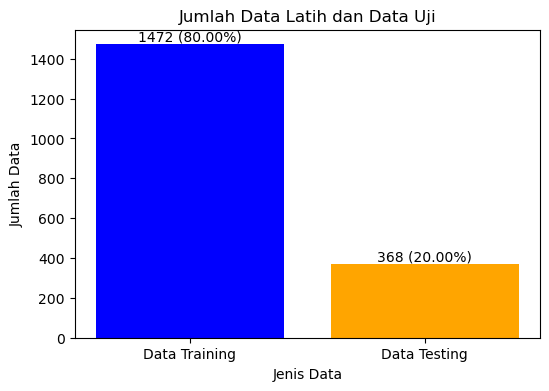

In [4]:
import matplotlib.pyplot as plt

train_size = len(x_train)
test_size = len(x_test)

plt.figure(figsize=(6, 4))
bars = plt.bar(['Data Training', 'Data Testing'], [train_size, test_size], color=['blue', 'orange' ])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height} ({height / (train_size+test_size) * 100 :.2f}%)',
        ha='center', va='bottom')

plt.title('Jumlah Data Latih dan Data Uji')
plt.xlabel('Jenis Data')
plt.ylabel('Jumlah Data')
plt.show()

# D.Modelling

In [8]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize models
models = {
"SVM": SVC(kernel='linear', random_state=42),
"KNN": KNeighborsClassifier(n_neighbors=5),
"Naive Bayes": MultinomialNB(),
}

# Train models
results = {}
for model_name, model in models.items():
    model.fit(x_train_vec, y_train)
    y_pred = model.predict(x_test_vec)
    results[model_name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, output_dict=True),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }


Confusion Matrix for SVM:


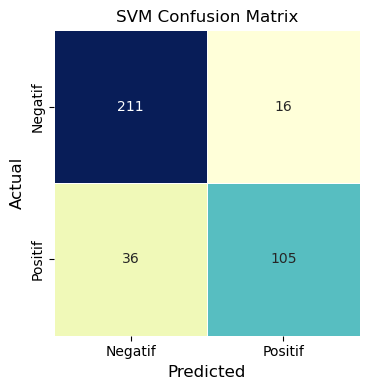


Confusion Matrix for KNN:


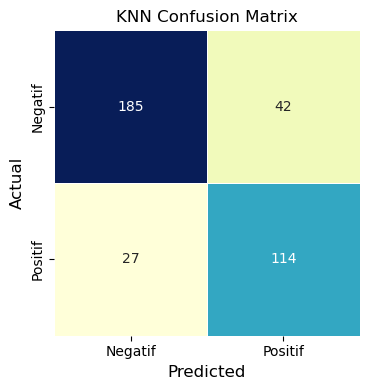


Confusion Matrix for Naive Bayes:


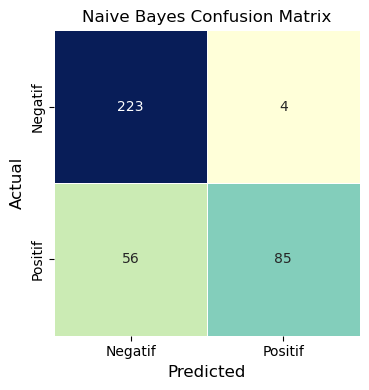

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

for model_name, result in results.items():
    fig, ax = plt.subplots(figsize=(4,4))
    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt='d',
        cmap="YlGnBu",
        cbar=False,
        xticklabels=['Negatif','Positif'],
        yticklabels=['Negatif','Positif'],
        ax=ax,
        square=True,
        linewidths = 0.5
    )

    print(f"\nConfusion Matrix for {model_name}:")
    ax.set_title(f"{model_name} Confusion Matrix", fontsize=12)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Actual", fontsize=12)

    plt.tight_layout()
    plt.show()

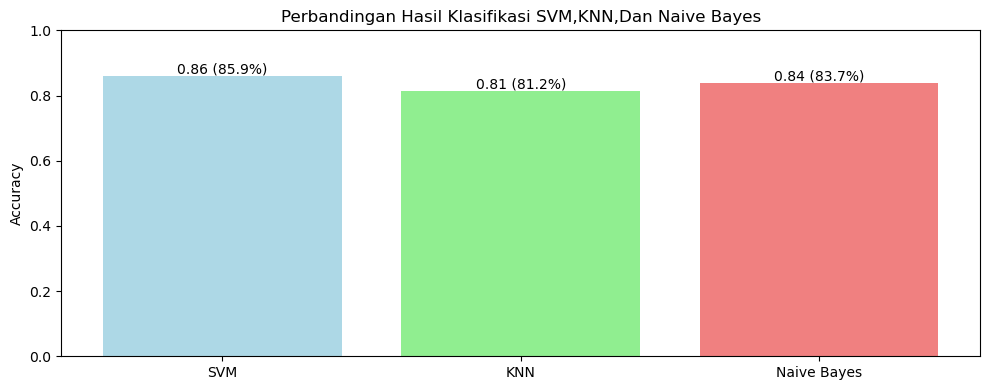

In [12]:
import matplotlib.pyplot as plt

accuracies = {model: result['accuracy'] for model, result in results.items()}

plt.figure(figsize=(10, 4))
bars = plt.bar(list(accuracies.keys()), list(accuracies.values()), color=['lightblue', 'lightgreen', 'lightcoral', 'plum'])

for bar in bars:
    accuracy = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        accuracy,
        f'{accuracy:.2f} ({accuracy * 100:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Perbandingan Hasil Klasifikasi SVM,KNN,Dan Naive Bayes")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt. show( )

In [14]:
from IPython.display import display

for model_name, result in results.items():
    print(f"\nClassification Report for {model_name}:")

    report_df = pd.DataFrame(result['classification_report' ]).transpose()

    styled_df = report_df.style.background_gradient(cmap="coolwarm")
    styled_df = styled_df.format(precision=3)
    display(styled_df)


Classification Report for SVM:


,precision,recall,f1-score,support
Negatif,0.854,0.930,0.890,227.000
Positif,0.868,0.745,0.802,141.000
accuracy,0.859,0.859,0.859,0.859
macro avg,0.861,0.837,0.846,368.000
weighted avg,0.859,0.859,0.856,368.000



Classification Report for KNN:


,precision,recall,f1-score,support
Negatif,0.873,0.815,0.843,227.000
Positif,0.731,0.809,0.768,141.000
accuracy,0.812,0.812,0.812,0.812
macro avg,0.802,0.812,0.805,368.000
weighted avg,0.818,0.812,0.814,368.000



Classification Report for Naive Bayes:


,precision,recall,f1-score,support
Negatif,0.799,0.982,0.881,227.000
Positif,0.955,0.603,0.739,141.000
accuracy,0.837,0.837,0.837,0.837
macro avg,0.877,0.793,0.810,368.000
weighted avg,0.859,0.837,0.827,368.000


In [19]:
# Uji coba dengan input manual dari user
user_review = input("Masukkan ulasan baru: ")

# Transformasi ulasan ke fitur
user_review_vec = vectorizer.transform([user_review])

# Prediksi sentimen
prediction = model.predict(user_review_vec)[0]

print(f"Ulasan: {user_review}")
print(f"Prediksi Sentimen: {prediction}")


Masukkan ulasan baru:  kalo mau full code lima puluh ribu


Ulasan: kalo mau full code lima puluh ribu
Prediksi Sentimen: Negatif


In [21]:
# Contoh ulasan buatan
new_reviews = [
    "Makanannya enak banget, pelayanan cepat, tempatnya nyaman sekali!",  # positif
    "Pesanan saya sangat lama, makanannya dingin, pelayanannya buruk.",  # negatif
    "Harga sesuai, rasa oke, recommended deh!",  # positif
    "Saya kecewa karena pesanannya salah dan staf tidak ramah."  # negatif
]

# Transformasi teks ke fitur
new_reviews_vec = vectorizer.transform(new_reviews)

# Prediksi sentimen
predictions = model.predict(new_reviews_vec)

# Tampilkan hasil
for review, label in zip(new_reviews, predictions):
    print(f"Ulasan: {review} \nPrediksi Sentimen: {label}\n")


Ulasan: Makanannya enak banget, pelayanan cepat, tempatnya nyaman sekali! 
Prediksi Sentimen: Positif

Ulasan: Pesanan saya sangat lama, makanannya dingin, pelayanannya buruk. 
Prediksi Sentimen: Negatif

Ulasan: Harga sesuai, rasa oke, recommended deh! 
Prediksi Sentimen: Positif

Ulasan: Saya kecewa karena pesanannya salah dan staf tidak ramah. 
Prediksi Sentimen: Negatif

